### OpenET Pre-2000 Collection v2.0 (1985-1999)

In [1]:
from datetime import timedelta, datetime
import pprint
import time

import ee
from IPython.display import Image, display
import ipyplot
import openet.core

ee.Initialize()

In [2]:
ensemble_coll = ee.ImageCollection('projects/openet/assets/ensemble/conus/gridmet/monthly/v2_0_pre2000')
ensemble_value_band = 'et_ensemble_mad'
model_coll = ee.ImageCollection('projects/openet/assets/ssebop/conus/gridmet/monthly/v2_0_pre2000')
model_value_band = 'et'
model_count_band = 'count'

years = list(range(1985, 2000))

region = ee.Geometry.BBox(-125.5, 25, -85.5, 50)

image_size = 600

et_palette = ['DEC29B', 'E6CDA1', 'EDD9A6', 'F5E4A9', 'FFF4AD', 'C3E683', '6BCC5C', '3BB369', '20998F', '1C8691', '16678A', '114982', '0B2C7A']
viridis = ['440154', '433982', '30678D', '218F8B', '36B677', '8ED542', 'FDE725']

land_mask = ee.Image('projects/openet/assets/features/water_mask').Not()
# Apply the NLCD/NALCMS water mask (anywhere it is water, set the ocean mask 
land_mask = land_mask.where(ee.Image("USGS/NLCD_RELEASES/2020_REL/NALCMS").unmask(18).eq(18), 0)


### Number of Monthly Images - Ensemble

8


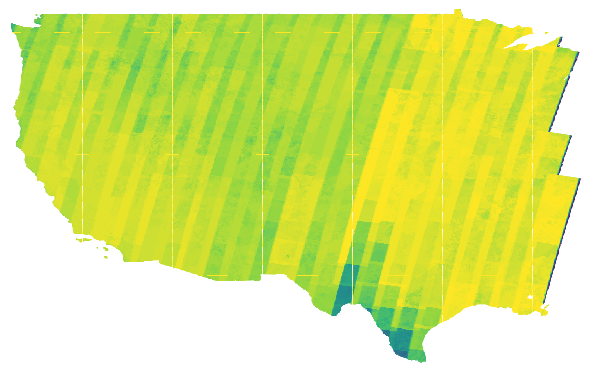

In [3]:
start_date = '1985-01-01'
end_date = '1993-01-01'
years = round(ee.Date(end_date).difference(ee.Date(start_date), 'year').getInfo())

image_url = (
    ensemble_coll.filterDate(start_date, end_date).select([ensemble_value_band]).count().divide(years)
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

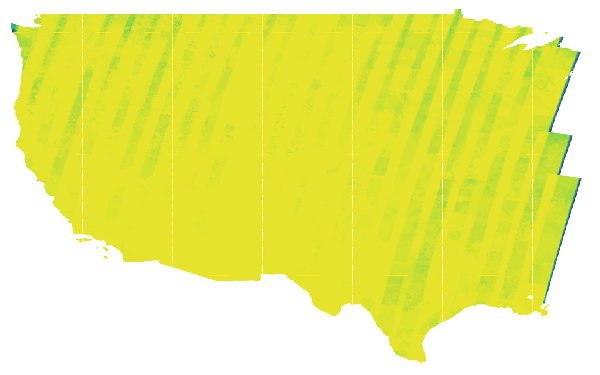

In [4]:
start_date = '1993-01-01'
end_date = '2000-01-01'
years = round(ee.Date(end_date).difference(ee.Date(start_date), 'year').getInfo())

image_url = (
    ensemble_coll.filterDate(start_date, end_date).select([ensemble_value_band]).count().divide(years)
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

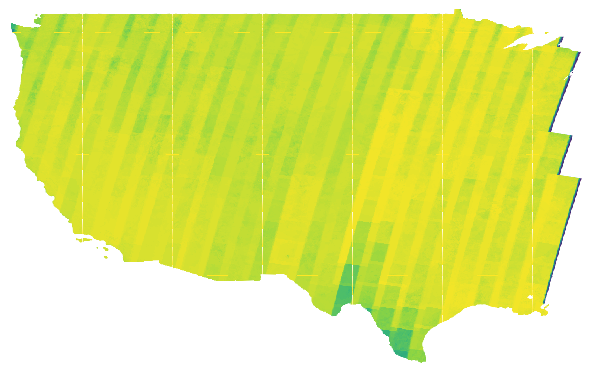

In [5]:
start_date = '1985-01-01'
end_date = '2000-01-01'
years = round(ee.Date(end_date).difference(ee.Date(start_date), 'year').getInfo())

image_url = (
    ensemble_coll.filterDate(start_date, end_date).select([ensemble_value_band]).count().divide(years)
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

### Number of Monthly Images - SSEBop

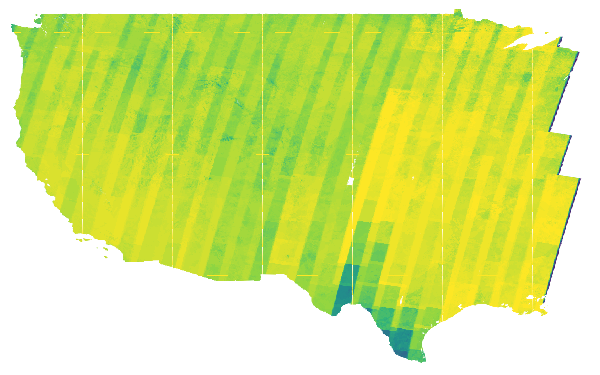

In [6]:
start_date = '1985-01-01'
end_date = '1993-01-01'
years = round(ee.Date(end_date).difference(ee.Date(start_date), 'year').getInfo())

image_url = (
    model_coll.filterDate(start_date, end_date).select([model_value_band]).count().divide(years)
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

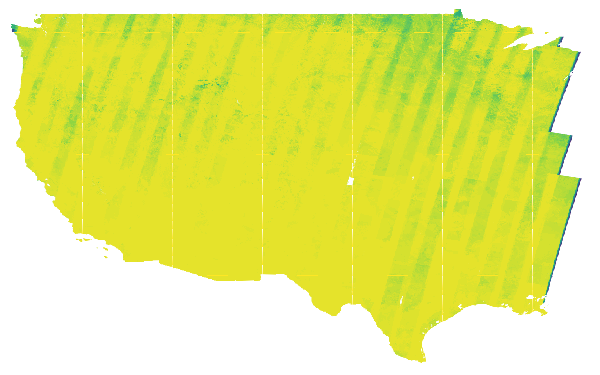

In [7]:
start_date = '1993-01-01'
end_date = '2000-01-01'
years = round(ee.Date(end_date).difference(ee.Date(start_date), 'year').getInfo())

image_url = (
    model_coll.filterDate(start_date, end_date).select([model_value_band]).count().divide(years)
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

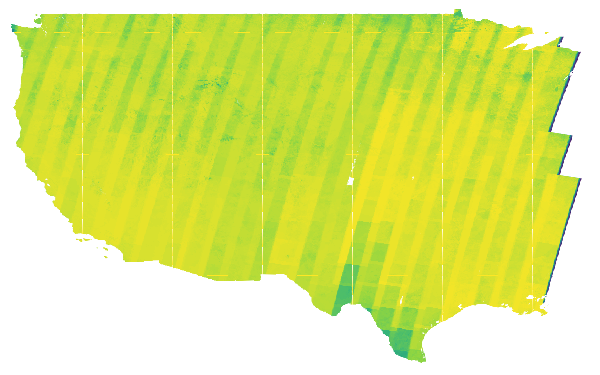

In [8]:
start_date = '1985-01-01'
end_date = '2000-01-01'
years = round(ee.Date(end_date).difference(ee.Date(start_date), 'year').getInfo())

image_url = (
    model_coll.filterDate(start_date, end_date).select([model_value_band]).count().divide(years)
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

### Average number of cloud free overpass images per month

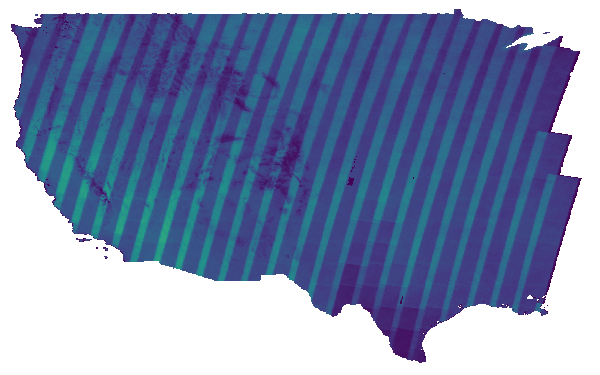

In [9]:
start_date = '1985-01-01'
end_date = '1993-01-01'

mask = model_coll.filterDate(start_date, end_date).select([model_value_band]).max().gt(0)
image_url = (
    model_coll.filterDate(start_date, end_date).select([model_count_band]).mean()
    .updateMask(mask)
    .visualize(min=0, max=4, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

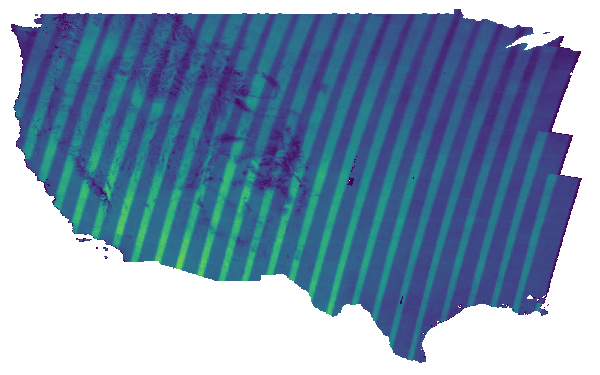

In [10]:
start_date = '1993-01-01'
end_date = '2000-01-01'

mask = model_coll.filterDate(start_date, end_date).select([model_value_band]).max().gt(0)
image_url = (
    model_coll.filterDate(start_date, end_date).select([model_count_band]).mean()
    .updateMask(mask)
    .visualize(min=0, max=4, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

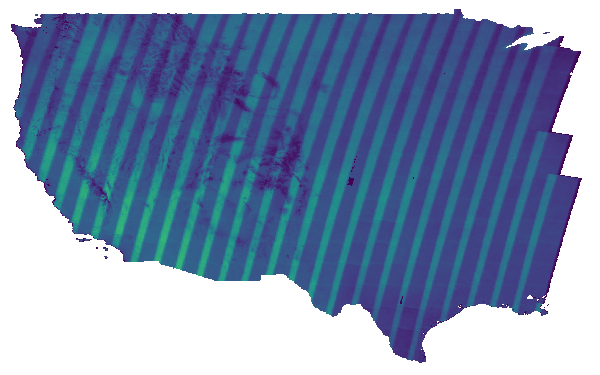

In [11]:
start_date = '1985-01-01'
end_date = '2000-01-01'

mask = model_coll.filterDate(start_date, end_date).select([model_value_band]).max().gt(0)
image_url = (
    model_coll.filterDate(start_date, end_date).select([model_count_band]).mean()
    .updateMask(mask)
    .visualize(min=0, max=4, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': image_size})
)
Image(image_url, embed=True, format='png')  

In [12]:
# for year in range(1985, 2000):
#     print(year)
#     image_url = (
#         monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').select([band_name]).count()
#         .visualize(min=0, max=12, palette=viridis)
#         .getThumbURL({'region': region, 'dimensions': image_size})
#     )
#     ipyplot.plot_images([image_url], img_width=image_size, show_url=False)
#     time.sleep(1)